Expected goals -- nonlinear spatial features

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score
)

from src.data.split_data import train_test_split_by_match
from src.visualization.plot_xg_surface import plot_xg_surface

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv("../../data/processed/shots.csv")

In [4]:
df["distance"] = np.sqrt(
    (120 - df["x"])**2 +
    (40 - df["y"])**2
)

In [5]:
goalpost_near = np.array([120, 36])
goalpost_far = np.array([120, 44])

shot_locations = df[["x", "y"]].values

vector_a = goalpost_near - shot_locations
vector_b = goalpost_far - shot_locations

dot_product = np.sum(vector_a * vector_b, axis=1)

magnitude_a = np.linalg.norm(vector_a, axis=1)
magnitude_b = np.linalg.norm(vector_b, axis=1)

cos_angle = dot_product / (magnitude_a * magnitude_b)
cos_angle = np.clip(cos_angle, -1, 1)

df["angle"] = np.arccos(cos_angle)

## Model 3 — Nonlinear Spatial

Model 2 assumes that distance and angle have linear effects on the
log-odds of scoring.

We now allow these relationships to be nonlinear by including polynomial
terms.

The model can be written as:

$$
P(Y_i=1 \mid d_i,\theta_i)
=
\frac{1}
{1+\exp(-\eta_i)}
$$

where

$$
\eta_i =
\beta_0
+\beta_1d_i
+\beta_2\theta_i
+\beta_3d_i^2
+\beta_4d_i\theta_i
+\beta_5\theta_i^2
$$

This allows the model to learn curvature and interactions between
distance and angle.

In [6]:
train, test = train_test_split_by_match(
    df,
    test_size=0.2,
    random_state=42
)

In [7]:
X_train = train[["distance", "angle"]]
y_train = train["goal"]

X_test = test[["distance", "angle"]]
y_test = test["goal"]

In [8]:
model_nonlinear = Pipeline([
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("logistic", LogisticRegression(max_iter=1000))
])

In [9]:
model_nonlinear.fit(
    X_train,
    y_train
)

Pipeline(steps=[('polynomial', PolynomialFeatures(include_bias=False)),
                ('logistic', LogisticRegression(max_iter=1000))])

In [10]:
test["xg_nonlinear"] = model_nonlinear.predict_proba(
    X_test
)[:, 1]

In [11]:
logloss_nonlinear = log_loss(
    y_test,
    test["xg_nonlinear"]
)

brier_nonlinear = brier_score_loss(
    y_test,
    test["xg_nonlinear"]
)

auc_nonlinear = roc_auc_score(
    y_test,
    test["xg_nonlinear"]
)

print(f"Log Loss:    {logloss_nonlinear:.4f}")
print(f"Brier Score: {brier_nonlinear:.4f}")
print(f"ROC AUC:     {auc_nonlinear:.4f}")

Log Loss:    0.2632
Brier Score: 0.0739
ROC AUC:     0.7537


In [12]:
poly = model_nonlinear.named_steps["polynomial"]

print(poly.get_feature_names_out(["distance", "angle"]))

['distance' 'angle' 'distance^2' 'distance angle' 'angle^2']


## Model Comparison

| Model | Log Loss | Brier Score | ROC AUC |
|---|---:|---:|---:|
| Constant probability | 0.2967 | 0.0796 | 0.5000 |
| Distance | 0.2667 | 0.0750 | 0.7398 |
| Distance + Angle | 0.2660 | 0.0746 | 0.7473 |
| Nonlinear Spatial | 0.2632 | 0.0739 | 0.7537 |

Model 3 specifically tests whether a more flexible spatial relationship improves on Model 2. And it does, although only a tiny bit. It seems like model 2 may already capture much of the useful spatial information and model 3 doesn't really add anything substantional.

## Visualization

In [13]:
def predict_nonlinear_xg(x, y):

    distance = np.sqrt(
        (120 - x)**2 +
        (40 - y)**2
    )

    shot_locations = np.column_stack((x, y))

    goalpost_near = np.array([120, 36])
    goalpost_far = np.array([120, 44])

    vector_a = goalpost_near - shot_locations
    vector_b = goalpost_far - shot_locations

    dot_product = np.sum(vector_a * vector_b, axis=1)

    magnitude_a = np.linalg.norm(vector_a, axis=1)
    magnitude_b = np.linalg.norm(vector_b, axis=1)

    cos_angle = dot_product / (
        magnitude_a * magnitude_b
    )

    cos_angle = np.clip(cos_angle, -1, 1)

    angle = np.arccos(cos_angle)

    X = pd.DataFrame({
        "distance": distance,
        "angle": angle
    })

    return model_nonlinear.predict_proba(X)[:, 1]

FileNotFoundError: [Errno 2] No such file or directory: '/Users/rothrebeka/Documents/GitHub/how-to-win-the-premier-league/reports/figures/xg_surfaces/model_3_nonlinear.png'

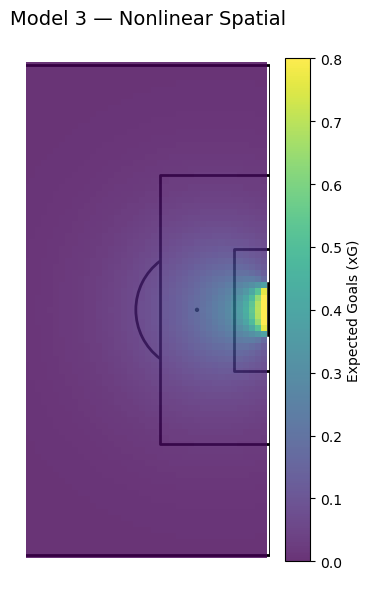

In [14]:
fig, ax = plot_xg_surface(
    predict_nonlinear_xg,
    title="Model 3 — Nonlinear Spatial",
    save_path="../../reports/figures/xg_surfaces/model_3_nonlinear.png"
)